# Checkpoint Week 3 — Decision Trees & Ensembles

Vul alle cellen in en push dit bestand naar je repo. De automatische checks (GitHub Actions) voeren dit notebook uit en controleren of alle **variabelen met de gevraagde namen** bestaan en correct zijn.

**BELANGRIJK**: gebruik exact de genoemde variabelennamen (`accuracy_voting`, `y_pred_voting`, `accuracy_bagging`, `accuracy_single_tree`, `y_pred_ada`, `accuracy_ada`, `f1_ada`, `y_pred_xgb`, `accuracy_xgb`, `f1_xgb`, `antwoord_tree_variatie`, `antwoord_ensemble`), anders faalt de controle.

**Gebruik in elke oefening `test_size=0.2` en `random_state=42`** bij de train/test-split, anders kunnen de checks afwijken.

---
# Oefening 1 — Decision Trees op de Wine dataset

- Laad de wine dataset via `sklearn.datasets.load_wine()`.
- Pas een `StandardScaler` toe op de features.
- Maak **twee** train/test-splits met `test_size=0.2`: één met `random_state=42` en één met `random_state=43` (dus een verschillende seed voor de split!).
- Train `clf1 = DecisionTreeClassifier(random_state=1)` op de eerste split en `clf2 = DecisionTreeClassifier(random_state=2)` op de tweede split.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# TODO: laad de wine dataset (features in X, targets in y)
X, y = load_wine(return_X_y=True, as_frame=True)

# TODO: pas een StandardScaler toe op X
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(X)

# TODO: maak twee splits met test_size=0.2
#       split 1 met random_state=42  -> X_train1, X_test1, y_train1, y_test1
#       split 2 met random_state=43  -> X_train2, X_test2, y_train2, y_test2
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled, y, test_size=0.2, random_state=43)

# TODO: train clf1 = DecisionTreeClassifier(random_state=1) op split 1
clf1 = DecisionTreeClassifier(random_state=1).fit(X_train1, y_train1)

# TODO: train clf2 = DecisionTreeClassifier(random_state=2) op split 2
clf2 = DecisionTreeClassifier(random_state=2).fit(X_train2, y_train2)


**Vraag (antwoord in `antwoord_tree_variatie`)**: Je vergelijkt de twee bomen (zelfde data, andere random state voor de split en voor de boom). Welke conclusie is correct? Kies A, B, C of D:

- A: Beide bomen zijn identiek, de random state heeft geen invloed op een decision tree
- B: Een decision tree is gevoelig voor kleine veranderingen in de trainingsdata (zoals een andere train/test-split), waardoor de structuur van de boom en de voorspellingen sterk kunnen verschillen — je kunt dus moeilijk voorspellen hoe een enkele boom zich gedraagt
- C: De bomen verschillen alleen in accuracy maar hebben altijd exact dezelfde structuur
- D: De random state bepaalt uitsluitend de snelheid waarmee de boom traint

In [3]:
antwoord_tree_variatie = "B"

Je kan van `sklearn.tree` de methode `plot_tree` importeren. Daar kan je een getraind model aan meegeven en de feature names en class names, en dan wordt er snel een mooie visualisatie gemaakt.

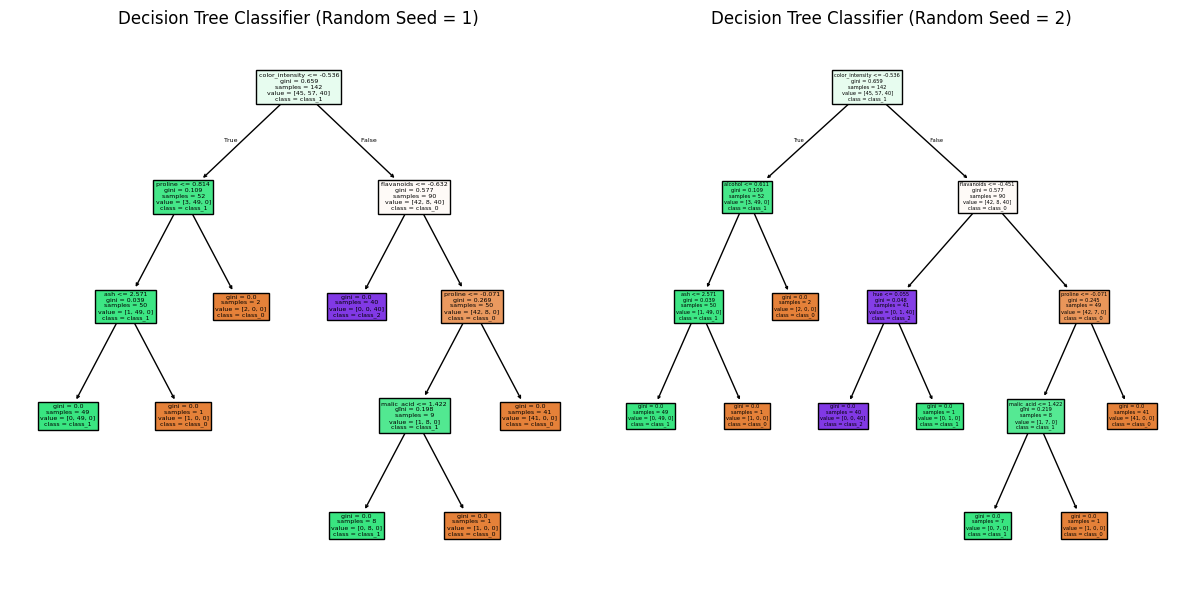

In [7]:
# We maken een prentje om ze naast elkaar weer te geven
wine = load_wine()
plt.figure(figsize=(12, 6))

# Links de eerste beslissingsboom
plt.subplot(1, 2, 1)
plot_tree(clf1, feature_names=wine.feature_names, class_names=wine.target_names, filled=True)
plt.title("Decision Tree Classifier (Random Seed = 1)")

# Rechts de tweede beslissingsboom
plt.subplot(1, 2, 2)
plot_tree(clf2, feature_names=wine.feature_names, class_names=wine.target_names, filled=True)
plt.title("Decision Tree Classifier (Random Seed = 2)")

plt.tight_layout()
plt.show()

Maak nu een simpeler model met enkel de eerste twee features van de dataset en plot de decision boundaries van beide bomen naast elkaar.

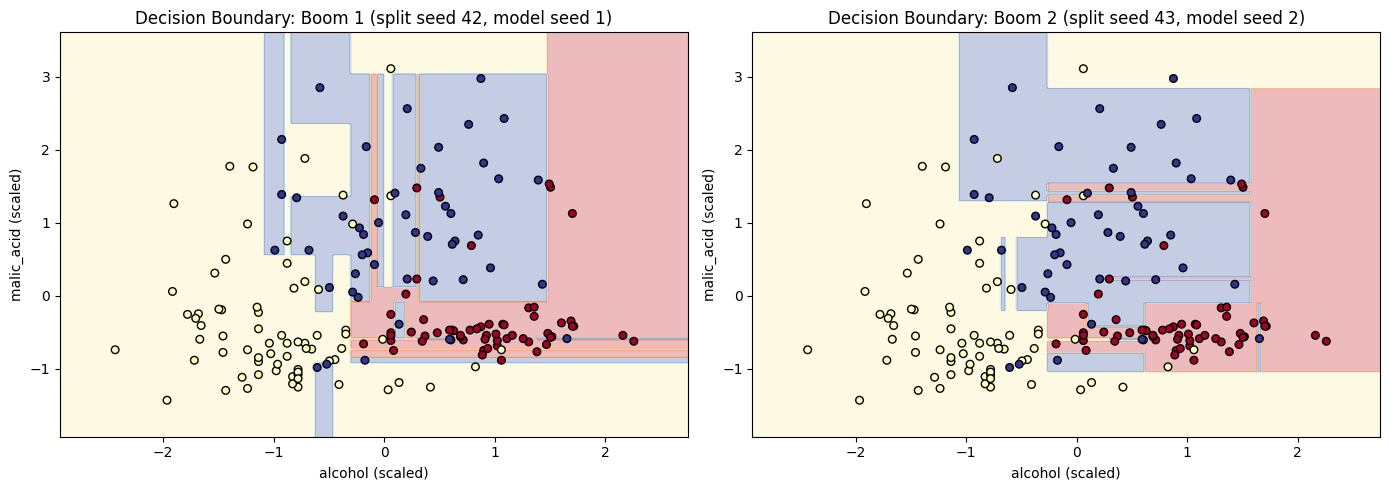

In [9]:
# TODO: laad de wine dataset opnieuw maar houd enkel de eerste twee features (X = wine.data[:, :2])
X = wine.data[:, :2]
X_scaled = scaler.fit_transform(X)
# TODO: maak opnieuw twee splits (test_size=0.2, random_state=42 en random_state=43)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled, y, test_size=0.2, random_state=43)
# TODO: train clf1 en clf2 op deze (kleinere) datasets
clf1 = DecisionTreeClassifier(random_state=1).fit(X_train1, y_train1)
clf2 = DecisionTreeClassifier(random_state=2).fit(X_train2, y_train2)
# TODO: maak een meshgrid over de eerste twee features en plot de decision boundary van elke boom
#       (hint: clf.predict op de punten van het meshgrid, daarna plt.contourf)
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
Z1 = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
Z1 = Z1.reshape(xx.shape)
plt.contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu,
    edgecolor="k",
    s=30,
)
plt.title("Decision Boundary: Boom 1 (split seed 42, model seed 1)")
plt.xlabel(f"{wine.feature_names[0]} (scaled)")
plt.ylabel(f"{wine.feature_names[1]} (scaled)")

plt.subplot(1, 2, 2)
Z2 = clf2.predict(np.c_[xx.ravel(), yy.ravel()])
Z2 = Z2.reshape(xx.shape)
plt.contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu,
    edgecolor="k",
    s=30,
)
plt.title("Decision Boundary: Boom 2 (split seed 43, model seed 2)")
plt.xlabel(f"{wine.feature_names[0]} (scaled)")
plt.ylabel(f"{wine.feature_names[1]} (scaled)")

plt.tight_layout()
plt.show()

---
# Oefening 2 — Voting classifier op de Breast Cancer dataset

- Laad de breast cancer dataset via `sklearn.datasets.load_breast_cancer()`.
- Pas een `StandardScaler` toe en splits met `test_size=0.2` en `random_state=42`.
- Maak drie classifiers: `knn_classifier = KNeighborsClassifier(5)`, `decision_tree_classifier = DecisionTreeClassifier(random_state=42)` en `svm_classifier = SVC(probability=True)`.
- Combineer ze in een `VotingClassifier` met `voting='soft'`.
- Sla de test-voorspellingen op in `y_pred_voting` en de **accuracy op de testset** in `accuracy_voting` (float).

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# TODO: laad de dataset en pas een StandardScaler toe
breast_cancer = load_breast_cancer()
X, y = breast_cancer.data, breast_cancer.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TODO: train/test split (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: maak knn_classifier (KNeighborsClassifier(5)), decision_tree_classifier
#       (DecisionTreeClassifier(random_state=42)) en svm_classifier (SVC(probability=True))
knn_classifier = KNeighborsClassifier(5)
decision_tree_classifier = DecisionTreeClassifier(random_state=42)
svm_classifier = CalibratedClassifierCV(SVC(), ensemble=False)

# TODO: maak voting_classifier (VotingClassifier met voting='soft')
voting_classifier = VotingClassifier(
    estimators=[("knn", knn_classifier), ("dt", decision_tree_classifier), ("svm", svm_classifier)],
    voting='soft')

# TODO: fit, voorspel op de testset en bereken de accuracy
voting_classifier = voting_classifier.fit(X_train, y_train)
y_pred_voting = voting_classifier.predict(X_test)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(accuracy_voting)

0.9736842105263158


**Vraag (antwoord in `antwoord_ensemble`)**: Waarom presteert een (soft) voting classifier vaak beter dan één enkele decision tree? Kies A, B, C of D:

- A: Omdat een voting classifier de features automatisch schaalt
- B: Omdat een voting classifier meer trainingsdata gebruikt dan een enkel model
- C: Omdat fouten van de individuele modellen elkaar deels opheffen: het ensemble combineert de voorspellingen (bij soft voting via de kansen) zodat individuele fouten minder doorwegen
- D: Omdat een voting classifier nooit overfit op de trainingsdata

In [13]:
antwoord_ensemble = "C"

Pas nu de `voting_classifier` aan naar `voting='hard'` en vergelijk de accuracy met de soft voting-variant. Bekijk daarna ook de individuele performantie van de onderliggende classifiers.

In [15]:
voting_classifier = VotingClassifier(
    estimators=[("knn", knn_classifier), ("dt", decision_tree_classifier), ("svm", svm_classifier)],
    voting='hard')
voting_classifier = voting_classifier.fit(X_train, y_train)
y_pred_voting = voting_classifier.predict(X_test)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(accuracy_voting)

individual_estimators = [knn_classifier, decision_tree_classifier, svm_classifier]
for estimator in individual_estimators:
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy van {estimator.__class__.__name__}: {accuracy:.4f}")

0.9649122807017544
Accuracy van KNeighborsClassifier: 0.9561
Accuracy van DecisionTreeClassifier: 0.9474
Accuracy van CalibratedClassifierCV: 0.9474


---
# Oefening 3 — Bagging op de Wine dataset

- Laad opnieuw de wine dataset (geen scaler nodig hier) en splits met `test_size=0.2` en `random_state=42`.
- Train een `BaggingClassifier` met als base estimator een `DecisionTreeClassifier`, `n_estimators=100` en `random_state=42`.
- Train ook één enkele `DecisionTreeClassifier(random_state=42)`.
- Sla de accuracy van bagging op in `accuracy_bagging` en van de enkele boom in `accuracy_single_tree` (beide floats).

In [17]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# TODO: laad de dataset en splits (test_size=0.2, random_state=42)
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: bagging met 100 bomen: BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42) en fit
bclf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)
bclf = bclf.fit(X_train, y_train)

# TODO: train ook één enkele DecisionTreeClassifier(random_state=42)
dclf = DecisionTreeClassifier(random_state=42)
dclf = dclf.fit(X_train, y_train)

# TODO: bereken accuracy_bagging en accuracy_single_tree
accuracy_bagging = accuracy_score(y_test, bclf.predict(X_test))
accuracy_single_tree = accuracy_score(y_test, dclf.predict(X_test))
print(accuracy_bagging, accuracy_single_tree)

0.9722222222222222 0.9444444444444444


---
# Oefening 4 — AdaBoost vs XGBoost op de Titanic dataset

Data voorbereiding (gebruik `data/titanic_dataset.csv`):
- Verwijder de kolommen `PassengerId`, `Name`, `Ticket` en `Cabin`.
- Vul ontbrekende waarden in `Age` aan met een `SimpleImputer(strategy='most_frequent')`.
- Encodeer `Sex` en `Embarked` met een `LabelEncoder`.
- Gebruik als features `['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']` en als target `Survived`.
- Splits met `test_size=0.2` en `random_state=42`.

Modellen (beide met 100 estimators en `random_state=42`):
- AdaBoost: `AdaBoostClassifier(n_estimators=100, random_state=42)` → `y_pred_ada`, en in de metriekencel: `accuracy_ada` en `f1_ada`.
- XGBoost: `XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)` → `y_pred_xgb`, en in de metriekencel: `accuracy_xgb` en `f1_xgb`.

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# data inladen
titanic = pd.read_csv("data/titanic_dataset.csv")

# TODO: verwijder de kolommen PassengerId, Name, Ticket en Cabin
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# TODO: vul ontbrekende waarden in Age aan met SimpleImputer(strategy='most_frequent')
imputer = SimpleImputer(strategy='most_frequent')
titanic[['Age']] = imputer.fit_transform(titanic[['Age']])

# TODO: encodeer Sex en Embarked met een LabelEncoder
encoder = LabelEncoder()
for col in ['Sex', 'Embarked']:
    titanic[col] = encoder.fit_transform(titanic[col])

# TODO: X = de features ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare'], y = 'Survived'
X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']]
y = titanic['Survived']

# TODO: train/test split (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### AdaBoost

In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# TODO: train ada_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_classifier = AdaBoostClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# TODO: maak voorspellingen op de testset
y_pred_ada = ada_classifier.predict(X_test)

In [30]:
# uitgebreide evaluatiemetrieken
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada)
recall_ada = recall_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)
confusion_ada = confusion_matrix(y_test, y_pred_ada)

print("AdaBoost Classifier metrieken:")
print(f"Accuracy: {accuracy_ada:.2f}")
print(f"Precision: {precision_ada:.2f}")
print(f"Recall: {recall_ada:.2f}")
print(f"F1 Score: {f1_ada:.2f}")
print("Confusion Matrix:")
print(confusion_ada)

AdaBoost Classifier metrieken:
Accuracy: 0.80
Precision: 0.76
Recall: 0.74
F1 Score: 0.75
Confusion Matrix:
[[88 17]
 [19 55]]


### XGBoost

In [31]:
# importeer de classifier. Mogelijk moet je conda omgeving aanpassen door XGBoost te installeren
from xgboost import XGBClassifier

In [32]:
# TODO: train xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42).fit(X_train, y_train)

# TODO: maak voorspellingen op de testset
y_pred_xgb = xgb_classifier.predict(X_test)

In [33]:
# uitgebreide scoringsmetrieken
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
confusion_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nXGBoost Classifier Metrics:")
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1 Score: {f1_xgb:.2f}")
print("Confusion Matrix:")
print(confusion_xgb)


XGBoost Classifier Metrics:
Accuracy: 0.82
Precision: 0.82
Recall: 0.72
F1 Score: 0.76
Confusion Matrix:
[[93 12]
 [21 53]]
